In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
b2 = rasterio.open("B2.tif")
b3 = rasterio.open("B3.tif")
b4 = rasterio.open("B4.tif")
b8 = rasterio.open("B8.tif")
b11 = rasterio.open("B11.tif")

In [3]:
print("B2:", b2.shape, b2.res)
print("B3:", b3.shape, b3.res)
print("B4:", b4.shape, b4.res)
print("B8:", b8.shape, b8.res)
print("B11:", b11.shape, b11.res)

B2: (2019, 1426) (10.0, 10.0)
B3: (2019, 1426) (10.0, 10.0)
B4: (2019, 1426) (10.0, 10.0)
B8: (2019, 1426) (10.0, 10.0)
B11: (1010, 714) (20.0, 20.0)


In [4]:
print("B8 CRS:", b8.crs)
print("B11 CRS:", b11.crs)

print("B8 NoData:", b8.nodata)
print("B11 NoData:", b11.nodata)

B8 CRS: EPSG:32644
B11 CRS: EPSG:32644
B8 NoData: 65535.0
B11 NoData: 65535.0


In [5]:
red = b4.read(1).astype("float32")
nir = b8.read(1).astype("float32")

In [6]:
red = np.ma.masked_equal(red, -99999)
nir = np.ma.masked_equal(nir, -99999)

In [7]:
ndvi = (nir - red) / (nir + red)

In [8]:
plt.figure(figsize=(8, 7))

<Figure size 800x700 with 0 Axes>

<Figure size 800x700 with 0 Axes>

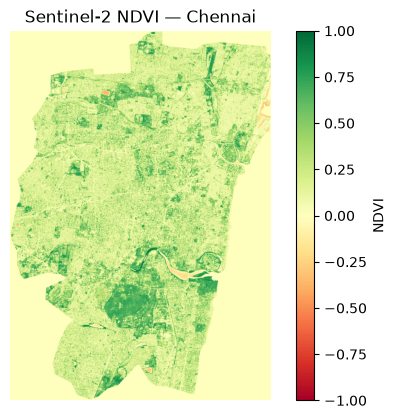

In [9]:
plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI — Chennai")
plt.axis("off")
plt.show()

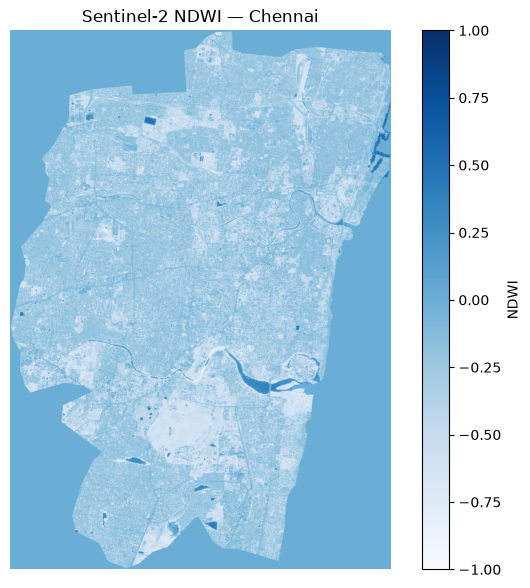

In [10]:
#NDWI
green = b3.read(1).astype("float32")
nir = b8.read(1).astype("float32")

green = np.ma.masked_equal(green, -99999)
nir = np.ma.masked_equal(nir, -99999)

ndwi = (green - nir) / (green + nir)

plt.figure(figsize=(8, 7))

plt.imshow(
    ndwi,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDWI")

plt.title("Sentinel-2 NDWI — Chennai")

plt.axis("off")

plt.show()

In [11]:
from rasterio.warp import reproject
from rasterio.enums import Resampling

In [12]:
swir = b11.read(1).astype("float32")

In [13]:
swir_resampled = np.empty(
    (b8.height, b8.width),
    dtype="float32"
)

In [14]:
reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11.transform,
    src_crs=b11.crs,
    dst_transform=b8.transform,
    dst_crs=b8.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)

(array([[65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        ...,
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.]],
       shape=(2019, 1426), dtype=float32),
 Affine(10.0, 0.0, 409930.0,
        0.0, -10.0, 1452090.0))

In [15]:
print("B8 shape:", b8.read(1).shape)
print("Resampled B11 shape:", swir_resampled.shape)

B8 shape: (2019, 1426)
Resampled B11 shape: (2019, 1426)


In [16]:
swir_resampled = np.ma.masked_equal(
    swir_resampled,
    -99999
)

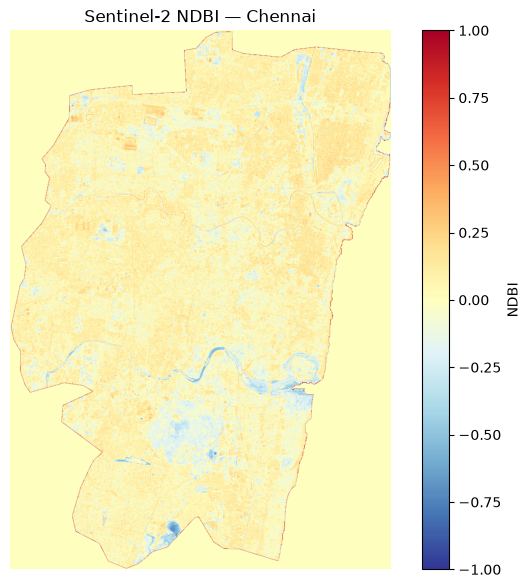

In [17]:
#NDBI
nir = b8.read(1).astype("float32")

nir = np.ma.masked_equal(
    nir,
    -99999
)

ndbi = (
    swir_resampled - nir
) / (
    swir_resampled + nir
)


plt.figure(figsize=(8, 7))

plt.imshow(
    ndbi,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDBI")

plt.title("Sentinel-2 NDBI — Chennai")

plt.axis("off")

plt.show()

In [20]:
red = b4.read(1).astype("float32")
blue = b2.read(1).astype("float32")
nir = b8.read(1).astype("float32")


red = np.ma.masked_equal(red, -99999)
blue = np.ma.masked_equal(blue, -99999)
nir = np.ma.masked_equal(nir, -99999)


print("B4 CRS:", b4.crs)
print("B8 CRS:", b8.crs)
print("B2 CRS:", b2.crs)

print("B4 NoData:", b4.nodata)
print("B8 NoData:", b8.nodata)
print("B2 NoData:", b2.nodata)

B4 CRS: EPSG:32644
B8 CRS: EPSG:32644
B2 CRS: EPSG:32644
B4 NoData: 65535.0
B8 NoData: 65535.0
B2 NoData: 65535.0


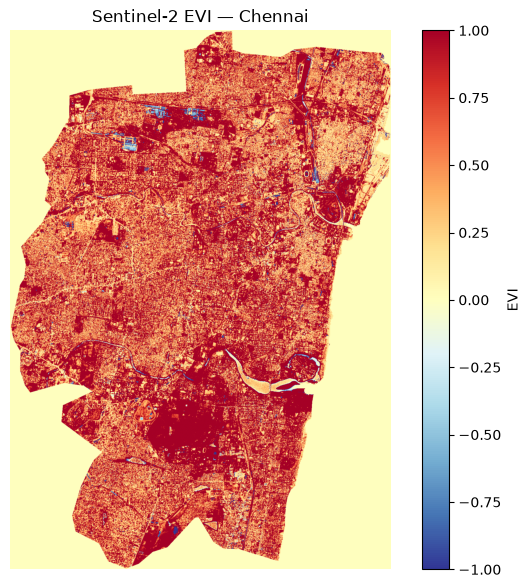

In [22]:
#EVI
evi = 2.5 * ((nir - red) / (nir + (6 * red) - (7.5 * blue) + 1))

plt.figure(figsize=(8, 7))

plt.imshow(
    evi,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="EVI")

plt.title("Sentinel-2 EVI — Chennai")

plt.axis("off")

plt.show()